In [56]:

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


def as_bool(x):
    if isinstance(x, str):
        return x.lower() == "true"
    return bool(x)


def yperiodic_string(x):
    return "true" if as_bool(x) else "false"


def results_geometry_folder(plot_type):
    """
    Zamienia nazwę geometrii używaną w funkcjach rysujących
    na nazwę katalogu w results/.
    """
    key = str(plot_type).lower()

    if key in ["pila", "piła", "bottom", "bottomup", "bottom-up", "saw"]:
        return "saw"

    if key in ["truesnake", "true_snake", "true-snake"]:
        return "truesnake"

    if key in ["snake", "semisnake", "semi-snake"]:
        return "snake"

    if key in ["snake_rows", "rows", "horizontal", "row-snake"]:
        return "snake_rows"

    raise ValueError(
        "Nieznany plot_type. Dostępne ścieżki: "
        "'saw'/'pila', 'truesnake', 'snake', 'snake_rows'."
    )


def load_component(path):
    with open(path, "r", encoding="utf-8") as f:
        header = f.readline().strip()

    mg_sites = [int(x) for x in header.replace("#", "").split() if x != "i"]

    data = np.loadtxt(path)
    sites = data[:, 0].astype(int)
    vals = data[:, 1:]

    return sites, vals, mg_sites


def bonds_pila(Nx, Ny, yperiodic=False):
    """
    Klasyczna numeracja typu piła / bottom-up.
    """
    Nsites = 2 * Nx * Ny
    bonds = []

    for i in range(1, Nsites):
        if i % 2 == 1:
            bonds.append((i, i + 1, "xx"))
        else:
            if i <= 2 * Ny * (Nx - 1):
                bonds.append((i, i + 2 * Ny - 1, "yy"))

            if i % (2 * Ny) != 0:
                bonds.append((i, i + 1, "zz"))
            elif yperiodic:
                col_start = i - 2 * Ny + 1
                bonds.append((i, col_start, "zz"))

    return Nsites, bonds


def site_index_snake_vertical(x, y, sub, Nx, Ny):
    """
    Semi-snake po kolumnach.
    Nieparzysta kolumna: y rośnie.
    Parzysta kolumna: y maleje.
    Kolejność A/B bez odwracania.
    """
    col_offset = 2 * Ny * (x - 1)
    yeff = y if x % 2 == 1 else Ny - y + 1

    return col_offset + 2 * (yeff - 1) + sub


def site_index_true_snake_vertical(x, y, sub, Nx, Ny):
    """
    True-snake po kolumnach.
    Nieparzysta kolumna: A, B.
    Parzysta kolumna: B, A.
    """
    col_offset = 2 * Ny * (x - 1)

    if x % 2 == 1:
        yeff = y
        subeff = sub
    else:
        yeff = Ny - y + 1
        subeff = 3 - sub

    return col_offset + 2 * (yeff - 1) + subeff


def bonds_from_indexer(Nx, Ny, yperiodic=False, indexer=site_index_snake_vertical):
    Nsites = 2 * Nx * Ny
    bonds = []

    def A(x, y):
        return indexer(x, y, 1, Nx, Ny)

    def B(x, y):
        return indexer(x, y, 2, Nx, Ny)

    for x in range(1, Nx + 1):
        for y in range(1, Ny + 1):

            bonds.append((A(x, y), B(x, y), "xx"))

            if y < Ny:
                bonds.append((B(x, y), A(x, y + 1), "zz"))
            elif yperiodic:
                bonds.append((B(x, y), A(x, 1), "zz"))

            if x < Nx:
                bonds.append((B(x, y), A(x + 1, y), "yy"))

    return Nsites, bonds


def bonds_snake(Nx, Ny, yperiodic=False):
    return bonds_from_indexer(
        Nx, Ny,
        yperiodic=yperiodic,
        indexer=site_index_snake_vertical
    )


def bonds_truesnake(Nx, Ny, yperiodic=False):
    return bonds_from_indexer(
        Nx, Ny,
        yperiodic=yperiodic,
        indexer=site_index_true_snake_vertical
    )


def site_index_snake_horizontal(x, y, sub, Nx, Ny):
    """
    Snake po wierszach.
    """
    row_offset = 2 * Nx * (y - 1)
    xeff = x if y % 2 == 1 else Nx - x + 1

    return row_offset + 2 * (xeff - 1) + sub


def bonds_snake_rows(Nx, Ny, yperiodic=False):
    """
    Snake po wierszach, zgodny z blokami długości 2*Nx.
    """
    Nsites = 2 * Nx * Ny
    bonds = []

    for i in range(1, Nsites):
        if i % 2 != 0:
            bonds.append((i, i + 1, "xx"))
        else:
            if i % (2 * Nx) != 0:
                bonds.append((i, i + 1, "yy"))

            if i <= 2 * Nx * (Ny - 1):
                bonds.append((i, i + 2 * Nx - 1, "zz"))
            elif yperiodic:
                bonds.append((i, i - 2 * Nx * (Ny - 1) + 1, "zz"))

    return Nsites, bonds


def get_bonds(Nx, Ny, plot_type="truesnake", yperiodic=False):
    plot_type = plot_type.lower()

    if plot_type in ["pila", "piła", "bottom", "bottomup", "bottom-up"]:
        return bonds_pila(Nx, Ny, yperiodic=yperiodic)

    if plot_type in ["snake", "semisnake", "semi-snake"]:
        return bonds_snake(Nx, Ny, yperiodic=yperiodic)

    if plot_type in ["truesnake", "true_snake", "true-snake"]:
        return bonds_truesnake(Nx, Ny, yperiodic=yperiodic)

    if plot_type in ["snake_rows", "rows", "horizontal", "row-snake"]:
        return bonds_snake_rows(Nx, Ny, yperiodic=yperiodic)

    raise ValueError(
        "Nieznany plot_type. Dostępne: "
        "'pila', 'snake', 'truesnake', 'snake_rows'."
    )


# ============================================================
#  Pozycje
# ============================================================

def honeycomb_positions_from_bonds(Nx, Ny, bonds):
    Nsites = 2 * Nx * Ny

    a = 1.0
    vx = (np.sqrt(3) * a,  a)
    vy = (np.sqrt(3) * a, -a)
    vz = (0.0,          2 * a)

    vmap = {
        "xx": vx,
        "yy": vy,
        "zz": vz,
    }

    adj = [[] for _ in range(Nsites + 1)]

    for s1, s2, bt in bonds:
        v = vmap[bt]
        adj[s1].append((s2, v))
        adj[s2].append((s1, (-v[0], -v[1])))

    pos = np.zeros((Nsites + 1, 2), dtype=float)
    placed = np.zeros(Nsites + 1, dtype=bool)

    pos[1] = (0.0, 0.0)
    placed[1] = True
    queue = [1]

    while queue:
        s = queue.pop(0)
        xs, ys = pos[s]

        for t, v in adj[s]:
            if not placed[t]:
                pos[t] = (xs + v[0], ys + v[1])
                placed[t] = True
                queue.append(t)

    return pos[1:]


def get_lattice_geometry(Nx, Ny, plot_type="truesnake", yperiodic=False):
    _, bonds = get_bonds(Nx, Ny, plot_type=plot_type, yperiodic=yperiodic)
    pos = honeycomb_positions_from_bonds(Nx, Ny, bonds)
    return bonds, pos

def make_current_path(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
    component,
    plot_type="truesnake",
    secondspin=False,
    fixed_pos=None,
):
    yp = yperiodic_string(yperiodic)
    geometry = results_geometry_folder(plot_type)

    if secondspin:
        filename = f"{component}_2spins_fixed{fixed_pos}"
    else:
        filename = component

    path = (
        f"results/{geometry}/{Nx}x{Ny}_PBC={yp}_Jx={Jx}_Jy={Jy}_Jz={Jz}_r={r}"
        f"/Savrg_theta={theta}_phi={phi}_{mg_site}/{filename}.dat"
    )

    return path

def load_spin_components(
    Nx, Ny,
    yperiodic,
    Jx, Jy, Jz,
    r,
    theta, phi,
    mg_site,
    plot_type="truesnake",
    secondspin=False,
    fixed_pos=None,
):
    """
    Wczytuje Sx, Sy, Sz dla aktualnych parametrów.

    Zwraca:
        sites, vals_x, vals_y, vals_z, mg_sites
    """

    components = ["Sx", "Sy", "Sz"]
    data = {}

    sites_ref = None
    mg_sites_ref = None

    for comp in components:
        path = make_current_path(
            Nx=Nx,
            Ny=Ny,
            yperiodic=yperiodic,
            Jx=Jx,
            Jy=Jy,
            Jz=Jz,
            r=r,
            theta=theta,
            phi=phi,
            mg_site=mg_site,
            component=comp,
            plot_type=plot_type,
            secondspin=secondspin,
            fixed_pos=fixed_pos,
        )

        sites, vals, mg_sites = load_component(path)

        if sites_ref is None:
            sites_ref = sites
            mg_sites_ref = mg_sites
        else:
            if not np.array_equal(sites, sites_ref):
                raise ValueError(f"Niezgodne indeksy site w pliku {comp}.dat")

            if mg_sites != mg_sites_ref:
                raise ValueError(f"Niezgodne mg_sites w pliku {comp}.dat")

        data[comp] = vals

    return sites_ref, data["Sx"], data["Sy"], data["Sz"], mg_sites_ref

from collections import defaultdict

def get_line_sites(
    Nx,
    Ny,
    center_site,
    plot_type="truesnake",
    direction="horizontal",
    yperiodic=False,
):
    """
    Zwraca numery site'ów leżących na wybranej linii przechodzącej
    przez center_site.

    direction:
        "horizontal"  -> linia po bondach xx + yy
        "vertical_xz" -> linia po bondach xx + zz
        "vertical_yz" -> linia po bondach yy + zz
    """

    # Pobieramy geometrię zgodną z wybraną numeracją
    bonds, pos = get_lattice_geometry(
        Nx,
        Ny,
        plot_type=plot_type,
        yperiodic=yperiodic,
    )

    direction = direction.lower()

    if direction in ["horizontal", "h"]:
        allowed_bonds = {"xx", "yy"}

        # Zaczynamy od najbardziej lewego końca
        def endpoint_sort_key(s):
            x, y = pos[s - 1]
            return (x, y)

    elif direction in ["vertical_xz", "xz", "v1"]:
        allowed_bonds = {"xx", "zz"}

        # Zaczynamy od najniższego końca
        def endpoint_sort_key(s):
            x, y = pos[s - 1]
            return (y, x)

    elif direction in ["vertical_yz", "yz", "v2"]:
        allowed_bonds = {"yy", "zz"}

        # Zaczynamy od najniższego końca
        def endpoint_sort_key(s):
            x, y = pos[s - 1]
            return (y, -x)

    else:
        raise ValueError(
            "Nieznany direction. Użyj: "
            "'horizontal', 'vertical_xz' albo 'vertical_yz'."
        )

    # Graf ograniczony tylko do wybranych typów bondów
    adj = defaultdict(list)

    for s1, s2, bond_type in bonds:
        if bond_type in allowed_bonds:
            adj[s1].append(s2)
            adj[s2].append(s1)

    # Znajdujemy całą spójną linię zawierającą center_site
    component = {center_site}
    stack = [center_site]

    while stack:
        s = stack.pop()

        for neigh in adj[s]:
            if neigh not in component:
                component.add(neigh)
                stack.append(neigh)

    # Końce tej linii: site'y mające tylko jednego sąsiada w komponencie
    endpoints = [
        s for s in component
        if sum(neigh in component for neigh in adj[s]) == 1
    ]

    # W otwartym układzie powinny być dwa końce
    start = min(endpoints, key=endpoint_sort_key)

    # Porządkujemy site'y od jednego końca do drugiego
    ordered_sites = []
    previous = None
    current = start

    while current is not None:
        ordered_sites.append(current)

        possible_next = [
            neigh for neigh in adj[current]
            if neigh in component and neigh != previous
        ]

        if not possible_next:
            break

        next_site = possible_next[0]
        previous, current = current, next_site

    return ordered_sites


def select_values_for_current_mg_site(vals, mg_sites, mg_site):
    """
    Wybiera właściwą kolumnę danych dla aktualnego mg_site.
    Jeśli vals jest 1D, zwraca go bez zmian.
    """
    if vals.ndim == 1:
        return vals

    if vals.ndim == 2:
        if mg_sites is None:
            raise ValueError("Dane są 2D, ale lista mg_sites nie została podana.")

        if mg_site not in mg_sites:
            raise ValueError(
                f"mg_site={mg_site} nie występuje w nagłówku pliku. "
                f"Dostępne mg_sites: {mg_sites}"
            )

        k = mg_sites.index(mg_site)
        return vals[:, k]

    raise ValueError(f"Nieobsługiwany wymiar danych vals.ndim={vals.ndim}.")


def get_values_on_line(values, sites, line_sites):
    """
    Z pełnego wektora wartości spinowych wybiera wartości
    dla site'ów należących do danej linii.
    """
    site_to_idx = {int(site): idx for idx, site in enumerate(sites)}

    line_values = []
    for site in line_sites:
        if site not in site_to_idx:
            raise ValueError(f"Site {site} nie występuje w plikach Sx/Sy/Sz.dat.")

        idx = site_to_idx[site]
        line_values.append(values[idx])

    return np.array(line_values, dtype=float)


def add_selected_sites_honeycomb_inset(
    ax,
    Nx,
    Ny,
    plot_type,
    yperiodic,
    selected_sites,
    ref_site,
    box=(0.73, 0.61, 0.26, 0.37),
    highlight_color="tab:orange",
    refsite_circle_color="black",
    show_labels=False,
):
    """
    Dodaje w prawym górnym rogu wykresu mały model honeycomb.
    Zaznaczone site'y to te używane na wykresie, a ref_site
    jest dodatkowo otoczony okręgiem.
    """
    selected_sites = [int(s) for s in selected_sites]
    selected_set = set(selected_sites)

    ax_inset = ax.inset_axes(box)

    bonds, pos = get_lattice_geometry(
        Nx,
        Ny,
        plot_type=plot_type,
        yperiodic=as_bool(yperiodic),
    )

    def get_pos(site):
        return pos[site - 1]

    selected_line_pairs = {
        tuple(sorted((s1, s2)))
        for s1, s2 in zip(selected_sites[:-1], selected_sites[1:])
    }

    for s1, s2, bond_type in bonds:
        p1 = get_pos(s1)
        p2 = get_pos(s2)
        bond_key = tuple(sorted((s1, s2)))

        if bond_key in selected_line_pairs:
            ax_inset.plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                color=highlight_color,
                linewidth=2.1,
                alpha=0.95,
                zorder=2,
            )
        else:
            ax_inset.plot(
                [p1[0], p2[0]],
                [p1[1], p2[1]],
                color="0.72",
                linewidth=0.9,
                alpha=0.9,
                zorder=1,
            )

    all_positions = np.array([get_pos(s) for s in range(1, len(pos) + 1)])

    ax_inset.scatter(
        all_positions[:, 0],
        all_positions[:, 1],
        s=38,
        facecolor="white",
        edgecolor="black",
        linewidth=0.7,
        zorder=3,
    )

    selected_positions = np.array([get_pos(s) for s in selected_sites])

    ax_inset.scatter(
        selected_positions[:, 0],
        selected_positions[:, 1],
        s=58,
        facecolor=highlight_color,
        edgecolor="black",
        linewidth=0.9,
        zorder=4,
    )

    ref_x, ref_y = get_pos(ref_site)
    dx_all = all_positions[:, 0].max() - all_positions[:, 0].min()
    dy_all = all_positions[:, 1].max() - all_positions[:, 1].min()
    ref_circle_radius = 0.045 * max(dx_all, dy_all)

    ref_circle = Circle(
        (ref_x, ref_y),
        radius=ref_circle_radius,
        fill=False,
        edgecolor=refsite_circle_color,
        linewidth=2.0,
        zorder=6,
    )
    ax_inset.add_patch(ref_circle)

    if show_labels:
        for s in range(1, len(pos) + 1):
            x0, y0 = get_pos(s)

            if s == ref_site or s in selected_set:
                color = "black"
                weight = "bold"
            else:
                color = "0.35"
                weight = "normal"

            ax_inset.text(
                x0,
                y0,
                str(s),
                ha="center",
                va="center",
                fontsize=5.5,
                color=color,
                fontweight=weight,
                zorder=7,
            )

    xmin, ymin = all_positions.min(axis=0)
    xmax, ymax = all_positions.max(axis=0)
    dx = xmax - xmin
    dy = ymax - ymin

    ax_inset.set_xlim(xmin - 0.12 * dx, xmax + 0.12 * dx)
    ax_inset.set_ylim(ymin - 0.16 * dy, ymax + 0.16 * dy)
    ax_inset.set_aspect("equal", adjustable="box")
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax_inset.set_title("")

    for spine in ax_inset.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("0.35")

    ax_inset.set_facecolor((1, 1, 1, 0.94))

    return ax_inset


def plot_current_line_spin_values(
    ref_site=None,
    direction="horizontal",
    plot_type="truesnake",
    log_y=False,
    eps=1e-15,
    figsize=(11, 5.5),
    marker="o",
    linewidth=2.0,
    markersize=6,
    show_site_line=True,
    show_honeycomb_inset=True,
    inset_show_labels=False,
    inset_box=(0.66, 0.55, 0.34, 0.50),
    inset_highlight_color="tab:orange",
    title=None,
):
    """
    Rysuje na jednym wykresie wartości <Sx^i>, <Sy^i>, <Sz^i>
    dla site'ów na linii wygenerowanej przez get_line_sites().
    """
    if ref_site is None:
        ref_site = mg_site

    line_sites = get_line_sites(
        Nx=Nx,
        Ny=Ny,
        center_site=ref_site,
        plot_type=plot_type,
        direction=direction,
        yperiodic=as_bool(yperiodic),
    )

    sites, vals_x, vals_y, vals_z, mg_sites = load_spin_components(
        Nx=Nx,
        Ny=Ny,
        yperiodic=yperiodic,
        Jx=Jx,
        Jy=Jy,
        Jz=Jz,
        r=r,
        theta=theta,
        phi=phi,
        mg_site=mg_site,
        plot_type=plot_type,
        secondspin=secondspin,
        fixed_pos=fixed_pos,
    )

    vals_x = select_values_for_current_mg_site(vals_x, mg_sites, mg_site)
    vals_y = select_values_for_current_mg_site(vals_y, mg_sites, mg_site)
    vals_z = select_values_for_current_mg_site(vals_z, mg_sites, mg_site)

    line_vals_x = get_values_on_line(vals_x, sites, line_sites)
    line_vals_y = get_values_on_line(vals_y, sites, line_sites)
    line_vals_z = get_values_on_line(vals_z, sites, line_sites)

    values = {"Sx": line_vals_x, "Sy": line_vals_y, "Sz": line_vals_z}
    x = np.arange(len(line_sites))

    if show_site_line:
        print("Site'y na wybranej linii:")
        print(line_sites)

    fig, ax = plt.subplots(figsize=figsize)

    for comp, vals in values.items():
        vals_to_plot = np.maximum(np.abs(vals), eps) if log_y else vals
        ax.plot(
            x,
            vals_to_plot,
            marker=marker,
            linewidth=linewidth,
            markersize=markersize,
            label=rf"${comp}$",
        )

    if log_y:
        ax.set_yscale("log")
        ax.set_ylabel(r"$|\langle S_\alpha^i\rangle|$")
    else:
        ax.axhline(0, linestyle="--", linewidth=1.0, alpha=0.6)
        ax.set_ylabel(r"$\langle S_\alpha^i\rangle$")

    ax.set_xticks(x)
    ax.set_xticklabels(line_sites)
    ax.set_xlabel("Site na wybranej linii")

    if title is None:
        title = (
            f"Wartości Sx, Sy, Sz na linii site'ów\n"
            f"linia: {direction}, ref_site={ref_site}, geometria: {plot_type}"
        )

    ax.set_title(title)
    ax.legend(title="Składowa", loc="upper left")

    if show_honeycomb_inset:
        add_selected_sites_honeycomb_inset(
            ax=ax,
            Nx=Nx,
            Ny=Ny,
            plot_type=plot_type,
            yperiodic=yperiodic,
            selected_sites=line_sites,
            ref_site=ref_site,
            box=inset_box,
            highlight_color=inset_highlight_color,
            show_labels=inset_show_labels,
        )

    ax.grid(True, which="both", linestyle=":", alpha=0.65)
    plt.tight_layout()
    plt.show()

    return line_sites, values


In [57]:
"""
    Rysuje wykres dla aktualnie ustawionych zmiennych:
    Nx, Ny, yperiodic, Jx, Jy, Jz, r, theta, phi,
    component, mg_site, secondspin, fixed_pos.

    plot_type:
        "pila"
        "snake"
        "truesnake"
        "snake_rows"
    """

Nx = 5
Ny = 4

secondspin = False
fixed_pos = 2

component = "Sx"
mg_site = 20

yperiodic = "false"

Jx = -1.0
Jy = -1.0
Jz = -1.0
r = 1.0

theta = 0.304*np.pi
phi = np.pi/4

Site'y na wybranej linii:
[3, 4, 14, 13, 19, 20, 30, 29, 35, 36]


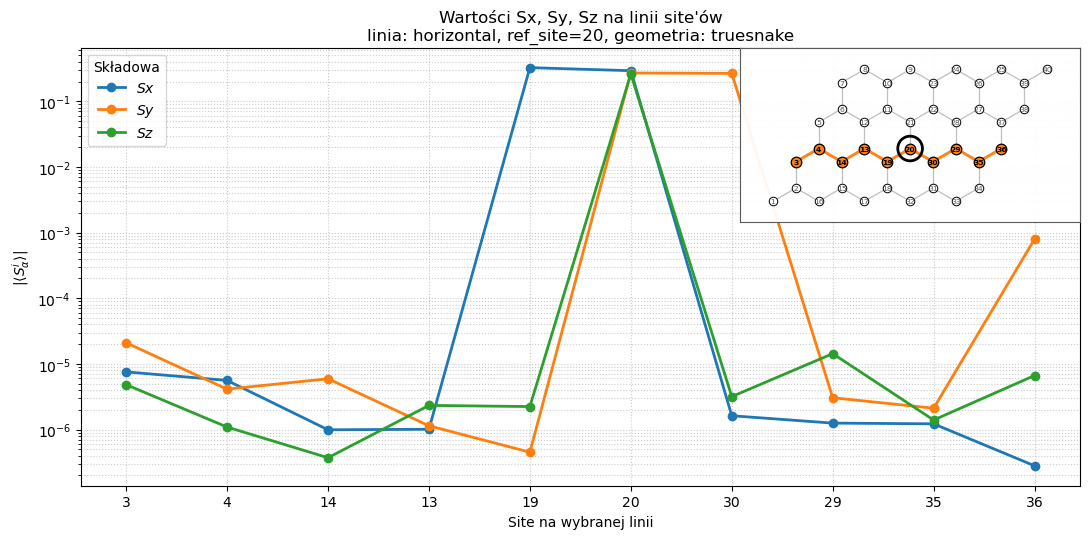

In [58]:
line_sites, spin_values = plot_current_line_spin_values(
    ref_site=20,
    direction="horizontal",  # "horizontal", "vertical_xz", "vertical_yz"
    plot_type="truesnake",  # "pila", "snake", "truesnake", "snake_rows"
    log_y=True,
    inset_show_labels=True,
)

In [51]:
from matplotlib.lines import Line2D


def plot_current_line_spin_values(
    ref_site=None,
    direction="horizontal",
    plot_type="truesnake",
    log_y=False,
    eps=1e-15,
    figsize=(11, 9.5),
    marker="o",
    linewidth=2.0,
    markersize=6,
    show_site_line=True,
    show_honeycomb_inset=True,
    inset_show_labels=False,
    inset_box=(0.68, 0.50, 0.34, 0.50),
    inset_highlight_color="tab:red",
    title=None,
):
    """
    Rysuje wartości <Sx^i>, <Sy^i>, <Sz^i> dla site'ów na linii
    wygenerowanej przez get_line_sites(), ale na 3 osobnych wykresach
    jeden pod drugim.

    Dodatkowo:
    - jedna wspólna legenda dla całej figury,
    - jeden inset honeycomb w prawym górnym rogu,
    - ref_site otoczony kółkiem w insecie.
    """

    if ref_site is None:
        ref_site = mg_site

    # --------------------------------------------------------
    # 1. Generujemy site'y na wybranej linii
    # --------------------------------------------------------

    line_sites = get_line_sites(
        Nx=Nx,
        Ny=Ny,
        center_site=ref_site,
        plot_type=plot_type,
        direction=direction,
        yperiodic=as_bool(yperiodic),
    )

    # --------------------------------------------------------
    # 2. Wczytujemy pełne dane z Sx.dat, Sy.dat, Sz.dat
    # --------------------------------------------------------

    sites, vals_x, vals_y, vals_z, mg_sites = load_spin_components(
        Nx=Nx,
        Ny=Ny,
        yperiodic=yperiodic,
        Jx=Jx,
        Jy=Jy,
        Jz=Jz,
        r=r,
        theta=theta,
        phi=phi,
        mg_site=mg_site,
        plot_type=plot_type,
        secondspin=secondspin,
        fixed_pos=fixed_pos,
    )

    # --------------------------------------------------------
    # 3. Jeśli dane są 2D, wybieramy kolumnę dla aktualnego mg_site
    # --------------------------------------------------------

    vals_x = select_values_for_current_mg_site(vals_x, mg_sites, mg_site)
    vals_y = select_values_for_current_mg_site(vals_y, mg_sites, mg_site)
    vals_z = select_values_for_current_mg_site(vals_z, mg_sites, mg_site)

    # --------------------------------------------------------
    # 4. Wybieramy tylko wartości dla site'ów z danej linii
    # --------------------------------------------------------

    line_vals_x = get_values_on_line(vals_x, sites, line_sites)
    line_vals_y = get_values_on_line(vals_y, sites, line_sites)
    line_vals_z = get_values_on_line(vals_z, sites, line_sites)

    values = {
        "Sx": line_vals_x,
        "Sy": line_vals_y,
        "Sz": line_vals_z,
    }

    colors = {
        "Sx": "tab:blue",
        "Sy": "tab:orange",
        "Sz": "tab:green",
    }

    x = np.arange(len(line_sites))

    # --------------------------------------------------------
    # 5. Informacyjny wydruk
    # --------------------------------------------------------

    if show_site_line:
        print("Site'y na wybranej linii:")
        print(line_sites)

    # --------------------------------------------------------
    # 6. Tworzymy 3 wykresy jeden pod drugim
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        3, 1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"hspace": 0}
    )

    component_order = ["Sx", "Sy", "Sz"]

    for ax, comp in zip(axes, component_order):
        vals = values[comp]

        if log_y:
            vals_to_plot = np.maximum(np.abs(vals), eps)
        else:
            vals_to_plot = vals

        ax.plot(
            x,
            vals_to_plot,
            marker=marker,
            linewidth=linewidth,
            markersize=markersize,
            color=colors[comp],
        )

        if not log_y:
            ax.axhline(0, linestyle="--", linewidth=1.0, alpha=0.6, color="0.4")

        ax.grid(True, which="both", linestyle=":", alpha=0.65)
        ax.set_ylabel(comp, color=colors[comp], fontsize=11)

        # Tytuł osi Y w sensie wartości fizycznej
        if log_y:
            ax.set_ylabel(
                rf"$| \langle {comp}^i \rangle |$",
                color=colors[comp],
                fontsize=11
            )
        else:
            ax.set_ylabel(
                rf"$\langle {comp}^i \rangle$",
                color=colors[comp],
                fontsize=11
            )

    # --------------------------------------------------------
    # 7. Skala Y
    # --------------------------------------------------------

    if log_y:
        for ax in axes:
            ax.set_yscale("log")

    # --------------------------------------------------------
    # 8. Oś X tylko na dolnym wykresie
    # --------------------------------------------------------

    # --------------------------------------------------------
    # Oś X na dole
    # --------------------------------------------------------

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(line_sites)
    axes[-1].set_xlabel("Site na wybranej linii")

    # --------------------------------------------------------
    # Numery site'ów także na górze pierwszego wykresu
    # --------------------------------------------------------

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(line_sites)

    axes[0].tick_params(
        axis="x",
        which="both",
        top=True,
        labeltop=True,
        bottom=False,
        labelbottom=False,
    )
    # --------------------------------------------------------
    # 9. Tytuł całej figury
    # --------------------------------------------------------

    if title is None:
        title = (
            f"Wartości Sx, Sy, Sz na linii site'ów\n"
            f"linia: {direction}, ref_site={ref_site}, geometria: {plot_type}"
        )

    fig.suptitle(title, y=0.98)

    # --------------------------------------------------------
    # 10. Jedna wspólna legenda dla całej figury
    # --------------------------------------------------------

    legend_handles = [
        Line2D([0], [0], color=colors["Sx"], marker=marker, linewidth=linewidth, label="Sx"),
        Line2D([0], [0], color=colors["Sy"], marker=marker, linewidth=linewidth, label="Sy"),
        Line2D([0], [0], color=colors["Sz"], marker=marker, linewidth=linewidth, label="Sz"),
    ]

    fig.legend(
        handles=legend_handles,
        labels=["Sx", "Sy", "Sz"],
        loc="upper left",
        bbox_to_anchor=(0.08, 0.98),
        ncol=1,
        frameon=True,
        title="Składowa",
    )

    # --------------------------------------------------------
    # 11. Jeden inset honeycomb na górnym wykresie
    # --------------------------------------------------------

    if show_honeycomb_inset:
        add_selected_sites_honeycomb_inset(
            ax=axes[0],
            Nx=Nx,
            Ny=Ny,
            plot_type=plot_type,
            yperiodic=yperiodic,
            selected_sites=line_sites,
            ref_site=ref_site,
            box=inset_box,
            highlight_color=inset_highlight_color,
            show_labels=inset_show_labels,
        )

    # --------------------------------------------------------
    # 12. Układ
    # --------------------------------------------------------

    plt.subplots_adjust(
        left=0.11,
        right=0.98,
        bottom=0.08,
        top=0.90,
        hspace=0.0,
    )
    plt.show()

    return line_sites, values

Site'y na wybranej linii:
[3, 4, 14, 13, 19, 20, 30, 29, 35, 36]


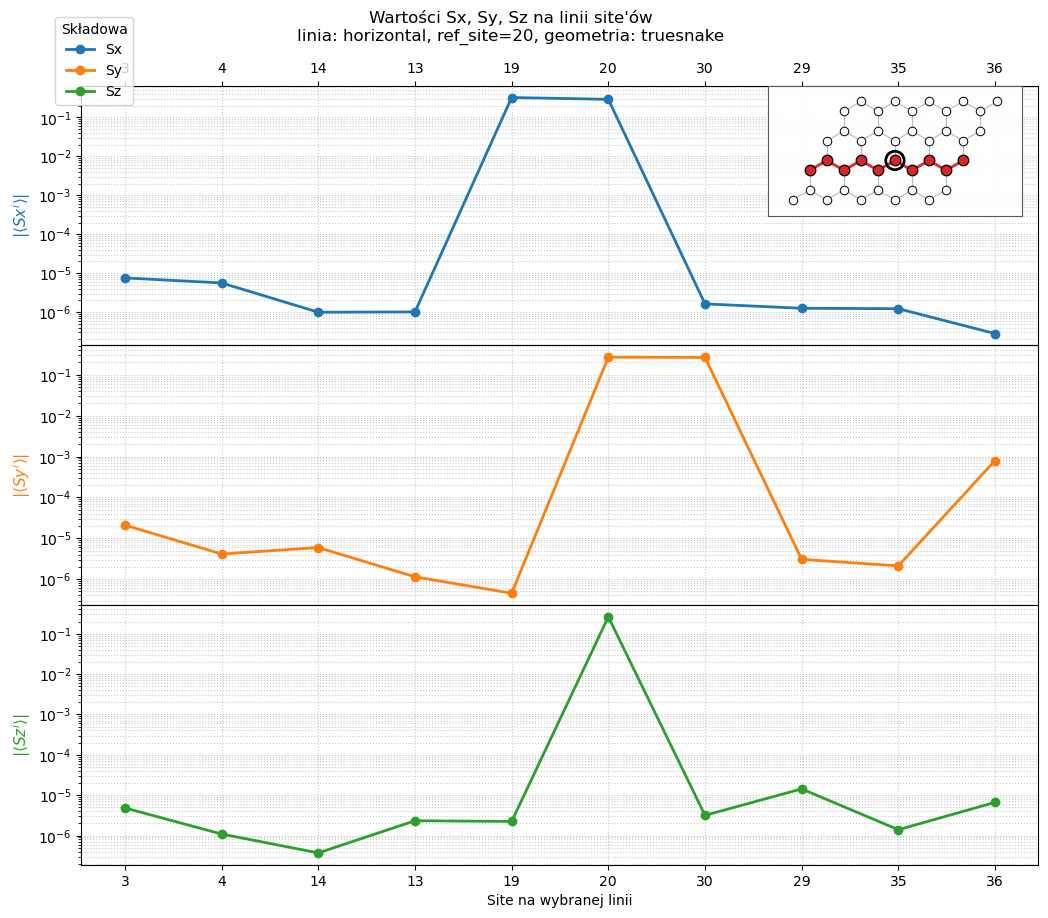

In [52]:
line_sites, spin_values = plot_current_line_spin_values(
    ref_site=20,
    direction="horizontal",
    plot_type="truesnake",
    log_y=True,
)